In [3]:
import pandas as pd 
from sklearn.datasets import load_breast_cancer
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
df = pd.DataFrame(X, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


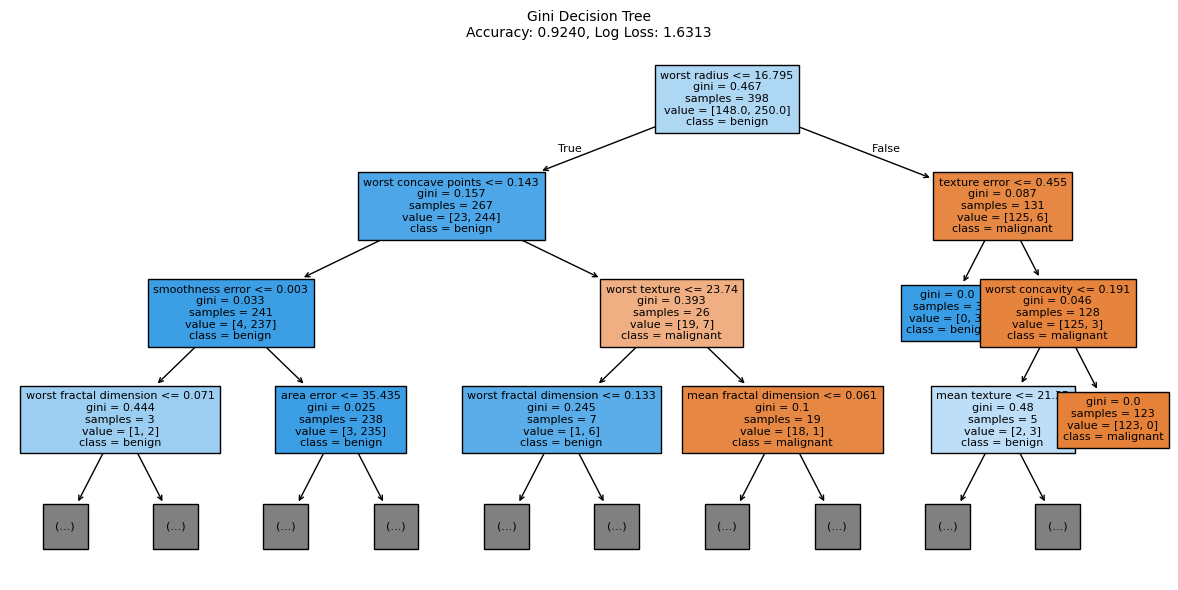

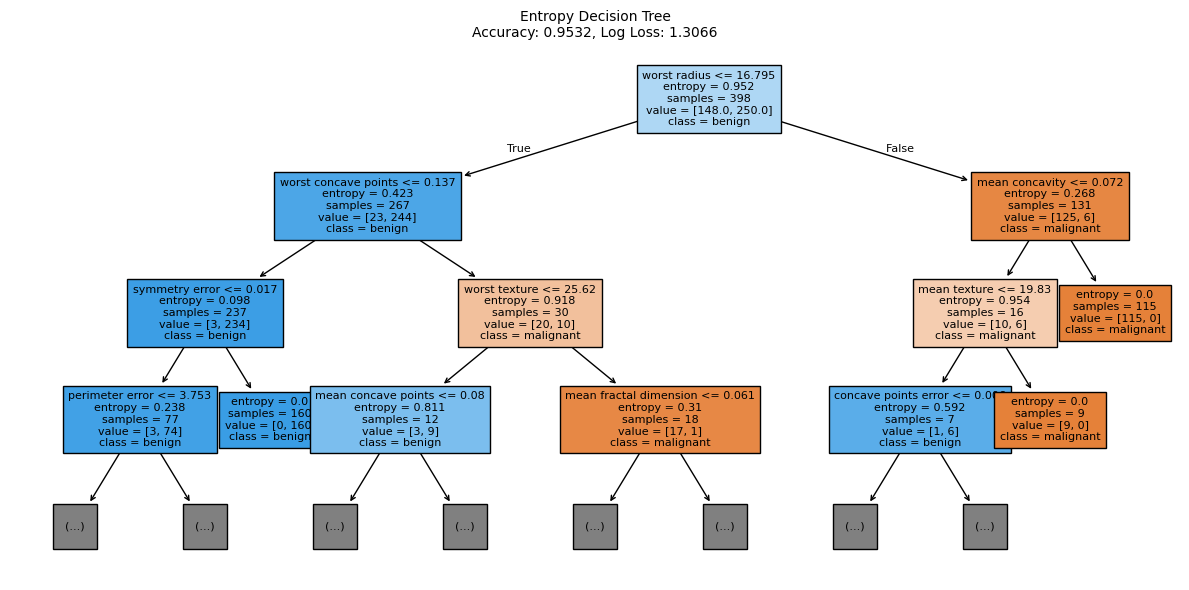

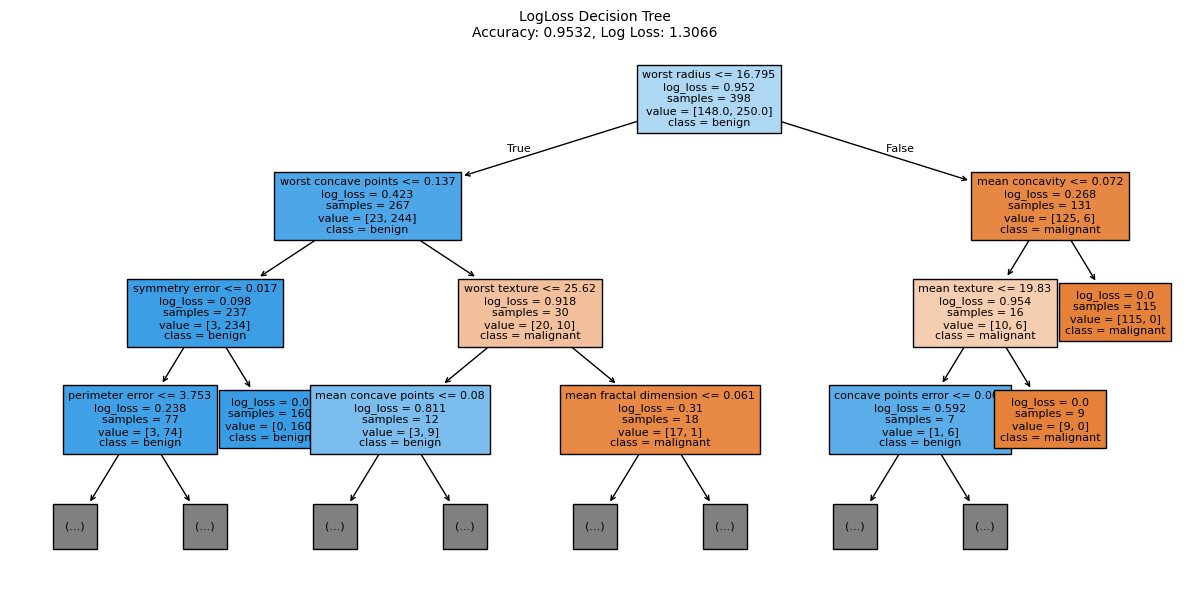

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.3, random_state=42, stratify=y
)
# Define models
models = {
   'Gini': DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42),
   'Entropy': DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42),
   'LogLoss': DecisionTreeClassifier(criterion='log_loss', max_depth=4, random_state=42),
}
# Train and evaluate
results = {}
for name, model in models.items():
   model.fit(X_train, y_train)
   probs = model.predict_proba(X_test)
   preds = model.predict(X_test)
   acc = accuracy_score(y_test, preds)
   loss = log_loss(y_test, probs)
   results[name] = {"model": model, "acc": acc, "loss": loss}
   # Plot and save each tree
   fig, ax = plt.subplots(figsize=(12, 6))
   plot_tree(
       model,
       feature_names=data.feature_names,
       class_names=data.target_names,
       filled=True,
       max_depth=3,
       fontsize=8,
       ax=ax
   )
   plt.title(f"{name} Decision Tree\nAccuracy: {acc:.4f}, Log Loss: {loss:.4f}", fontsize=10)
   plt.tight_layout()
   plt.savefig(f"{name}_tree.png", dpi=300)
   plt.show()